# Time Series EDA
- Crop yield / long-term trends forecasting
- Rainfall analysis
- Price forecasting

This notebook works through: converting to a time series, visual inspection, rolling statistics, ADF stationarity testing, transformation (log + differencing), and re-testing.

**Series used:**
- **Maize (white) retail price** — monthly national average (2006–2020)
- **Rainfall** — monthly national average (2006–2026)


## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
%matplotlib inline

## Load datasets

The rainfall data has already been merged into the price data, so we only need **`wfp_with_rainfall.csv`**.

In [4]:
df = pd.read_csv("wfp_with_rainfall.csv", parse_dates=["date"])
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22,2006-01-01,17.813333
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58,2006-01-01,17.813333
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47,2006-01-01,17.813333
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15,2006-01-01,17.813333
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24,2006-01-01,44.527500


In [5]:
df.shape, df["date"].min(), df["date"].max()

((27316, 18),
 Timestamp('2006-01-15 00:00:00'),
 Timestamp('2026-08-15 00:00:00'))

## 1. Convert the data to a time series format

The raw data is at the market x commodity x month level. We aggregate to a single **national monthly average** for:
- Maize (white), Retail price
- Rainfall (mm)

In [6]:
maize = df[(df["commodity"] == "Maize (white)") & (df["pricetype"] == "Retail")]

price_ts = maize.groupby("date")["price"].mean().sort_index()
price_ts.index = pd.DatetimeIndex(price_ts.index).to_period("M").to_timestamp()

rain_ts = df.groupby("date")["rainfall_mm"].mean().sort_index()
rain_ts.index = pd.DatetimeIndex(rain_ts.index).to_period("M").to_timestamp()

print("Maize price series:", price_ts.shape, price_ts.index.min(), "->", price_ts.index.max())
print("Rainfall series:   ", rain_ts.shape, rain_ts.index.min(), "->", rain_ts.index.max())

Maize price series: (180,) 2006-01-01 00:00:00 -> 2020-12-01 00:00:00
Rainfall series:    (248,) 2006-01-01 00:00:00 -> 2026-08-01 00:00:00


Note: rainfall data extends further (to 2026) than maize price data (to 2020). Keep this in mind if you later combine the two series — you'll want to restrict to the overlapping window.

## 2. Plot the time series data to visually inspect trends

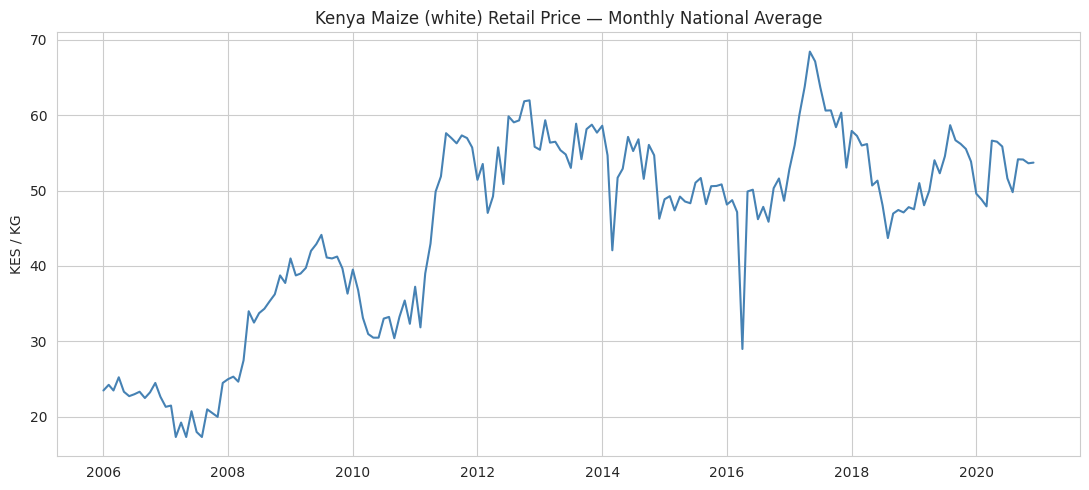

In [7]:
plt.figure(figsize=(11, 5))
plt.plot(price_ts, color="steelblue")
plt.title("Kenya Maize (white) Retail Price — Monthly National Average")
plt.ylabel("KES / KG")
plt.tight_layout()
plt.show()

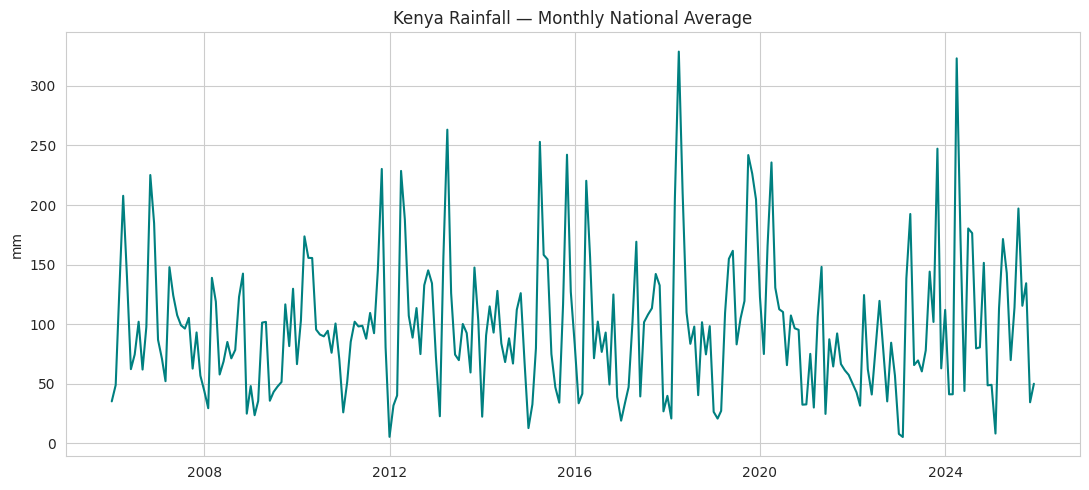

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(rain_ts, color="teal")
plt.title("Kenya Rainfall — Monthly National Average")
plt.ylabel("mm")
plt.tight_layout()
plt.show()

**Observations:**
- Maize price shows a strong long-run upward trend (roughly tripling from 2006 to 2020), a sharp crash/spike around 2016, and generally rising volatility — a classic non-stationary series.
- Rainfall oscillates around a fairly stable mean with a clear yearly seasonal cycle — no obvious trend, so it is likely closer to stationary already.

## 3. Calculate and plot rolling statistics

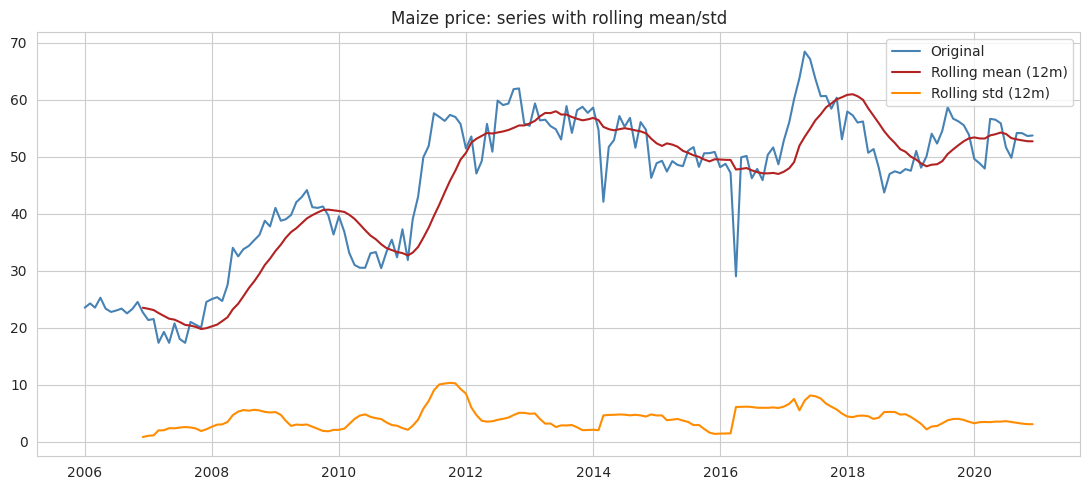

In [9]:
def rolling_plot(series, label, window=12):
    roll_mean = series.rolling(window).mean()
    roll_std = series.rolling(window).std()
    plt.figure(figsize=(11, 5))
    plt.plot(series, label="Original", color="steelblue")
    plt.plot(roll_mean, label=f"Rolling mean ({window}m)", color="firebrick")
    plt.plot(roll_std, label=f"Rolling std ({window}m)", color="darkorange")
    plt.title(f"{label}: series with rolling mean/std")
    plt.legend()
    plt.tight_layout()
    plt.show()

rolling_plot(price_ts, "Maize price")

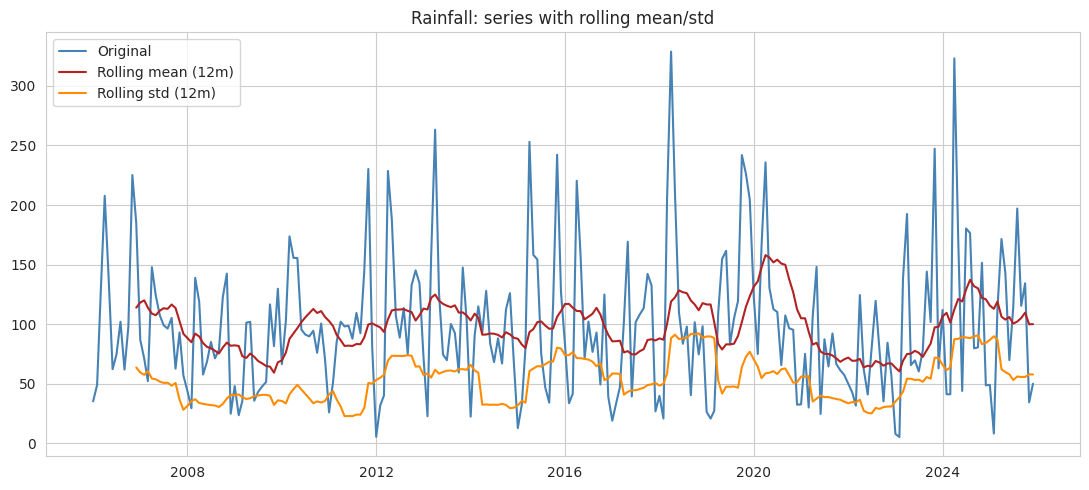

In [10]:
rolling_plot(rain_ts, "Rainfall")

For maize price, the rolling mean is clearly not flat — it drifts upward over time, another sign of non-stationarity. Rainfall's rolling mean is comparatively flat, while its rolling std shows a repeating seasonal wobble.

## 4. Perform ADF test on the original series
Records: ADF test statistic, p-value, number of lags, critical values.

In [11]:
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF test: {label} ---")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.5f}")
    print(f"# lags used   : {result[2]}")
    print(f"# observations: {result[3]}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"   {k}: {v:.4f}")
    print()
    return result

adf_price_raw = adf_report(price_ts, "Maize price (original)")

--- ADF test: Maize price (original) ---
ADF statistic : -1.9155
p-value       : 0.32480
# lags used   : 1
# observations: 178
Critical values:
   1%: -3.4676
   5%: -2.8779
   10%: -2.5755



In [12]:
adf_rain_raw = adf_report(rain_ts, "Rainfall (original)")

--- ADF test: Rainfall (original) ---
ADF statistic : -4.3837
p-value       : 0.00032
# lags used   : 13
# observations: 226
Critical values:
   1%: -3.4596
   5%: -2.8744
   10%: -2.5736



**Reading the results:**
- Maize price: p-value ≈ 0.32 (well above 0.05) → **fail to reject** the null of a unit root → **non-stationary**.
- Rainfall: p-value ≈ 0.0003 (well below 0.05) → **reject** the null → already **stationary**. This matches the visual inspection above.

## 5. Decide whether transformation is necessary

- **Maize price** is non-stationary with a strong trend and increasing variance → apply a **log transform** (stabilizes variance) followed by **first-order differencing** (removes the trend).
- **Rainfall** is already stationary in levels, so differencing isn't required to achieve stationarity — but rainfall is strongly *seasonal*, so a **seasonal difference (lag 12)** is useful if you want to strip out the yearly cycle and study anomalies (e.g. drought/flood years) rather than the raw seasonal swing.

In [13]:
# Maize: log transform + first-order differencing
log_price = np.log(price_ts)
log_price_diff = log_price.diff().dropna()

# Rainfall: seasonal differencing (lag 12)
rain_diff = rain_ts.diff(12).dropna()

## 6. Plot the transformed/differenced series

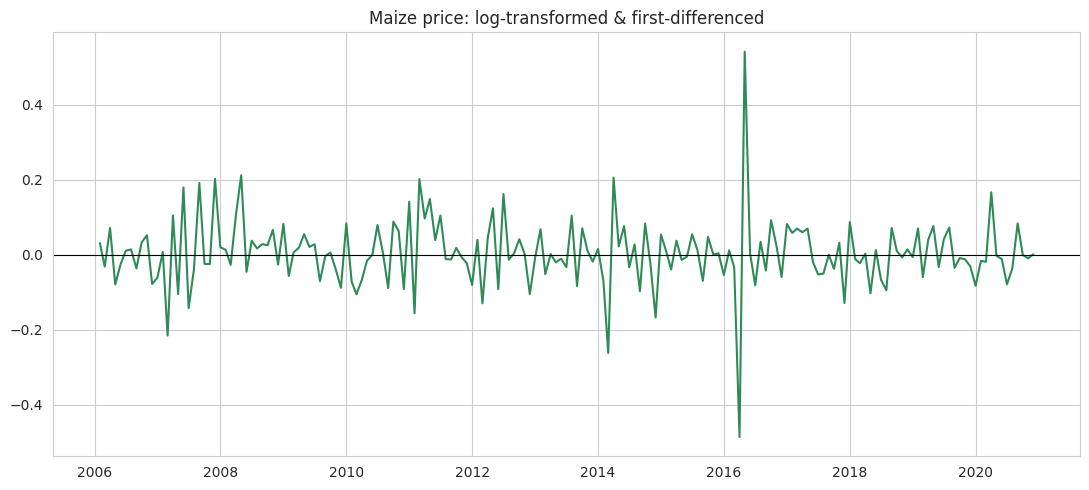

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(log_price_diff, color="seagreen")
plt.title("Maize price: log-transformed & first-differenced")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

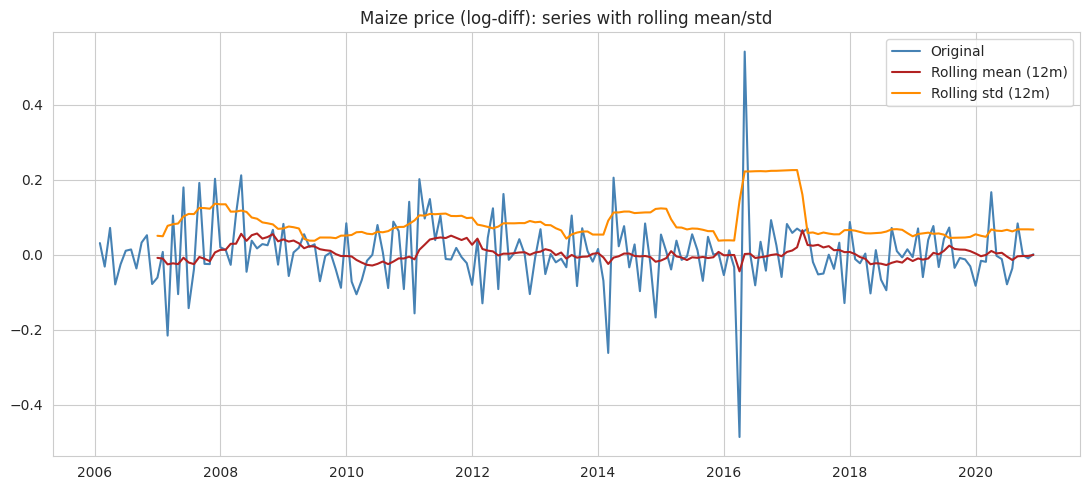

In [15]:
rolling_plot(log_price_diff, "Maize price (log-diff)")

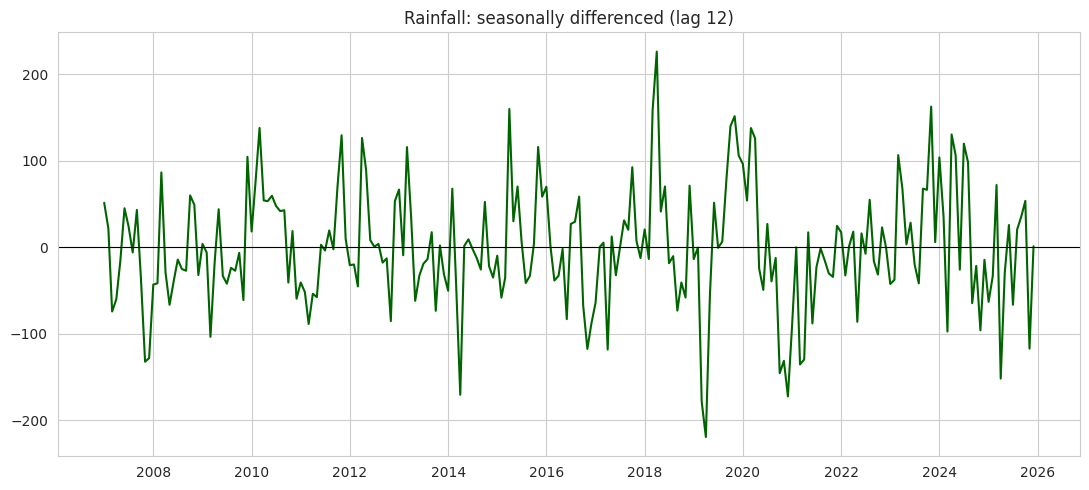

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(rain_diff, color="darkgreen")
plt.title("Rainfall: seasonally differenced (lag 12)")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

The differenced maize price series now fluctuates around zero with a roughly constant rolling mean and std — much closer to stationary. The seasonally-differenced rainfall series shows deviations from the typical yearly pattern (positive = wetter than usual for that month, negative = drier).

## 7. Perform ADF again

In [17]:
adf_price_diff = adf_report(log_price_diff, "Maize price (log, 1st-differenced)")

--- ADF test: Maize price (log, 1st-differenced) ---
ADF statistic : -18.5194
p-value       : 0.00000
# lags used   : 0
# observations: 178
Critical values:
   1%: -3.4676
   5%: -2.8779
   10%: -2.5755



In [18]:
adf_rain_diff = adf_report(rain_diff, "Rainfall (seasonally differenced, lag 12)")

--- ADF test: Rainfall (seasonally differenced, lag 12) ---
ADF statistic : -4.9967
p-value       : 0.00002
# lags used   : 13
# observations: 214
Critical values:
   1%: -3.4613
   5%: -2.8751
   10%: -2.5740



**Result:** both transformed series now have p-values effectively at 0 → **reject the null of a unit root** → both are **stationary**. The log-differenced maize price series and the seasonally-differenced rainfall series are ready for stationarity-dependent modeling (e.g. ARIMA on the maize price, or using the rainfall anomaly as an exogenous regressor).

## Summary

In [19]:
summary = pd.DataFrame([
    {"series": "Maize price (original)", "ADF stat": adf_price_raw[0], "p-value": adf_price_raw[1],
     "lags": adf_price_raw[2], "n obs": adf_price_raw[3], "stationary (5%)": adf_price_raw[1] < 0.05},
    {"series": "Maize price (log, differenced)", "ADF stat": adf_price_diff[0], "p-value": adf_price_diff[1],
     "lags": adf_price_diff[2], "n obs": adf_price_diff[3], "stationary (5%)": adf_price_diff[1] < 0.05},
    {"series": "Rainfall (original)", "ADF stat": adf_rain_raw[0], "p-value": adf_rain_raw[1],
     "lags": adf_rain_raw[2], "n obs": adf_rain_raw[3], "stationary (5%)": adf_rain_raw[1] < 0.05},
    {"series": "Rainfall (seasonally differenced)", "ADF stat": adf_rain_diff[0], "p-value": adf_rain_diff[1],
     "lags": adf_rain_diff[2], "n obs": adf_rain_diff[3], "stationary (5%)": adf_rain_diff[1] < 0.05},
])
summary

,series,ADF stat,p-value,lags,n obs,stationary (5%)
0,Maize price (original),-1.915511,3.248000e-01,1,178,False
1,"Maize price (log, differenced)",-18.519416,2.109639e-30,0,178,True
2,Rainfall (original),-4.383717,3.171599e-04,13,226,True
3,Rainfall (seasonally differenced),-4.996708,2.252855e-05,13,214,True


---
# Rainfall Analysis: Seasonal Decomposition

Rainfall is strongly seasonal but not trending, so rather than modeling it directly, it's more useful to split it into **trend**, **seasonal**, and **residual** components. The residual is where drought/flood anomalies show up — months that were much wetter or drier than the seasonal pattern would predict.

Missing rainfall months before cleanup:
date
2026-01-01   NaN
2026-02-01   NaN
2026-03-01   NaN
2026-04-01   NaN
2026-05-01   NaN
2026-06-01   NaN
2026-07-01   NaN
2026-08-01   NaN
Freq: MS, Name: rainfall_mm, dtype: float64


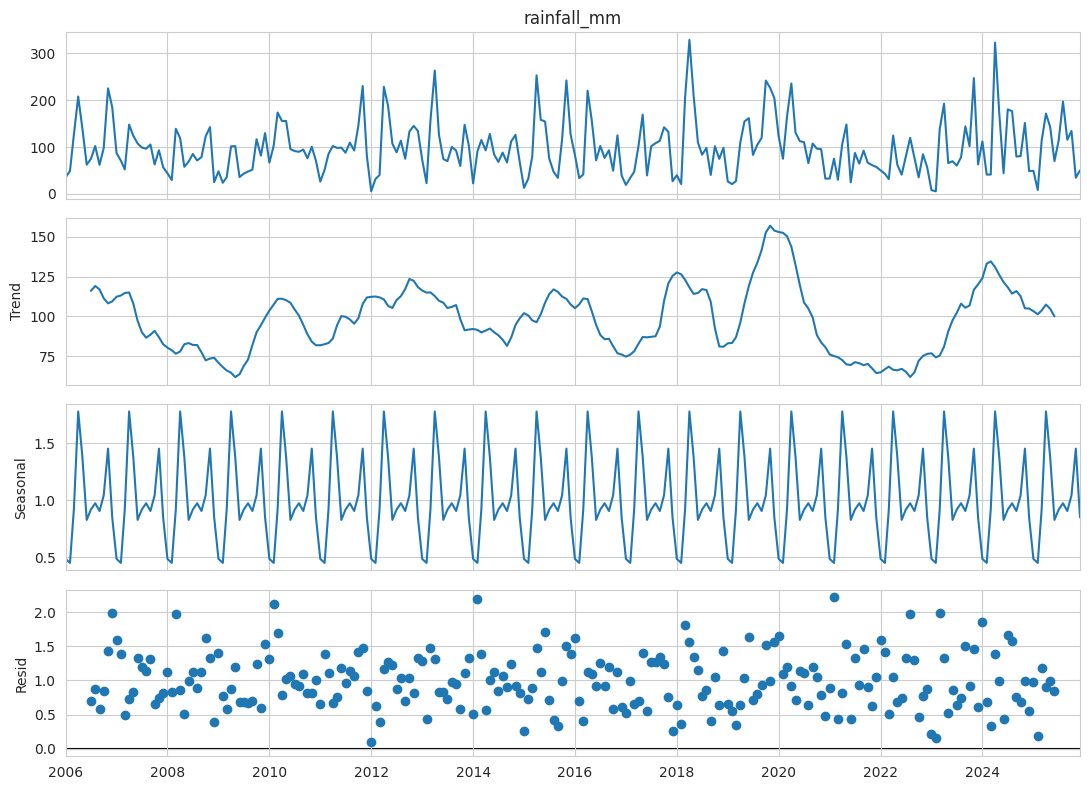

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# A few of the most recent months have missing rainfall values (not yet recorded) —
# seasonal_decompose can't handle NaNs, so drop any leading/trailing missing months.
print("Missing rainfall months before cleanup:")
print(rain_ts[rain_ts.isna()])

rain_ts_clean = rain_ts.dropna()

# Multiplicative decomposition suits rainfall well since variance scales with the
# seasonal level (e.g. a "wet season" month varies more in absolute mm than a dry one).
# Rainfall can be 0 in some months, so guard against divide-by-zero by using additive
# if any zeros are present.
if (rain_ts_clean == 0).any():
    model_type = "additive"
else:
    model_type = "multiplicative"

decomp = seasonal_decompose(rain_ts_clean, model=model_type, period=12)

fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

**Reading the decomposition:**
- **Trend**: the smoothed long-run level of rainfall — should be roughly flat if there's no long-term drying/wetting trend.
- **Seasonal**: the repeating within-year pattern (Kenya's long-rains/short-rains cycle).
- **Residual**: what's left after removing trend and seasonality — sustained negative stretches indicate drought periods, sustained positive stretches indicate unusually wet periods (flood risk).

In [21]:
# Flag the driest and wettest residual months as candidate drought/flood signals
resid = decomp.resid.dropna()
print("Top 5 driest anomalies (relative to seasonal norm):")
print(resid.sort_values().head(5))
print()
print("Top 5 wettest anomalies (relative to seasonal norm):")
print(resid.sort_values(ascending=False).head(5))

Top 5 driest anomalies (relative to seasonal norm):
date
2012-01-01    0.101460
2023-02-01    0.161125
2025-02-01    0.181691
2023-01-01    0.213522
2017-12-01    0.252339
Name: resid, dtype: float64

Top 5 wettest anomalies (relative to seasonal norm):
date
2021-02-01    2.216948
2014-02-01    2.197106
2010-02-01    2.124996
2023-03-01    1.990867
2006-12-01    1.983852
Name: resid, dtype: float64


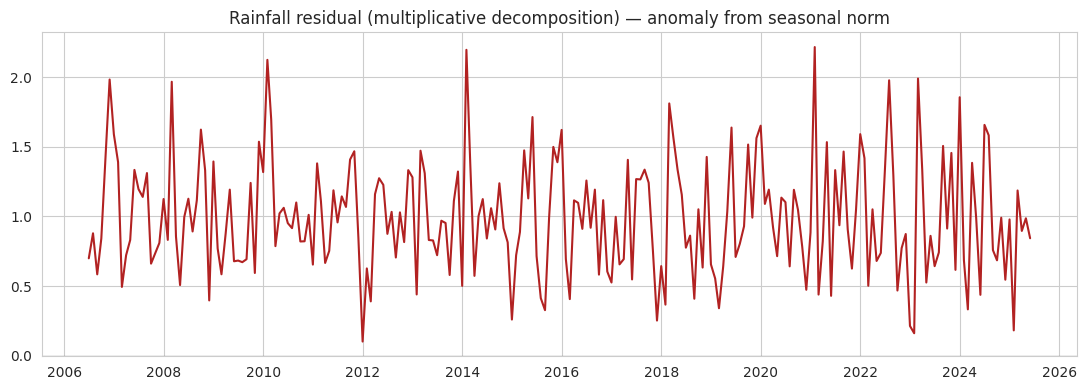

In [22]:
plt.figure(figsize=(11, 4))
plt.plot(resid, color="firebrick")
plt.axhline(0, color="black", lw=0.8)
plt.title(f"Rainfall residual ({model_type} decomposition) — anomaly from seasonal norm")
plt.tight_layout()
plt.show()

Note: `rain_ts` (used later for the price forecast) still has the full range including any trailing missing months — the SARIMAX section below re-aligns it against the price series anyway, so this doesn't cause issues downstream.

---
# Price Forecasting: SARIMA / SARIMAX

We model the **log maize price** with a seasonal ARIMA. Two versions are fit:
1. **SARIMA** — price only, no external inputs.
2. **SARIMAX** — same model, with **rainfall as an exogenous regressor**, since rainfall affects maize supply and therefore price (often with a lag, since a drought affects the harvest, not the same month's price).

Since rainfall data only overlaps with price data through Dec 2020, both series are restricted to that shared window.

In [23]:
# Align to the overlapping window (price data ends earlier than rainfall data)
common_start = max(log_price.index.min(), rain_ts.index.min())
common_end = min(log_price.index.max(), rain_ts.index.max())

log_price_aligned = log_price.loc[common_start:common_end]
rain_aligned = rain_ts.loc[common_start:common_end]

print(f"Aligned range: {common_start.date()} to {common_end.date()}  ({len(log_price_aligned)} months)")

Aligned range: 2006-01-01 to 2020-12-01  (180 months)


In [24]:
# Train/test split — hold out the last 12 months for evaluation
n_test = 12
train_price = log_price_aligned.iloc[:-n_test]
test_price = log_price_aligned.iloc[-n_test:]
train_rain = rain_aligned.iloc[:-n_test]
test_rain = rain_aligned.iloc[-n_test:]

print("Train:", train_price.index.min(), "->", train_price.index.max(), f"({len(train_price)} obs)")
print("Test: ", test_price.index.min(), "->", test_price.index.max(), f"({len(test_price)} obs)")

Train: 2006-01-01 00:00:00 -> 2019-12-01 00:00:00 (168 obs)
Test:  2020-01-01 00:00:00 -> 2020-12-01 00:00:00 (12 obs)


**Model order:** based on the earlier ADF results, the price series needs **d=1** (first differencing) to become stationary, and rainfall showed a 12-month seasonal cycle, so we include a seasonal term with `s=12`. Starting point: `SARIMA(1,1,1)(1,1,0,12)` — a reasonable general-purpose order for a trending, seasonally-influenced series. In practice you'd tune this further with `pmdarima.auto_arima` or by inspecting ACF/PACF plots.

In [25]:
order = (1, 1, 1)
seasonal_order = (1, 1, 0, 12)

# --- Model A: SARIMA, price only ---
model_sarima = sm.tsa.statespace.SARIMAX(
    train_price,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_sarima = model_sarima.fit(disp=False)
print(fit_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                 112.723
Date:                             Mon, 31 Aug 2026   AIC                           -217.446
Time:                                     05:42:54   BIC                           -205.622
Sample:                                 01-01-2006   HQIC                          -212.641
                                      - 12-01-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3752      0.188     -1.992      0.046      -0.744      -0.006
ma.L1         -0.0269      

In [26]:
# --- Model B: SARIMAX, price with rainfall as exogenous regressor ---
model_sarimax = sm.tsa.statespace.SARIMAX(
    train_price,
    exog=train_rain,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_sarimax = model_sarimax.fit(disp=False)
print(fit_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                 113.565
Date:                             Mon, 31 Aug 2026   AIC                           -217.129
Time:                                     05:43:10   BIC                           -202.350
Sample:                                 01-01-2006   HQIC                          -211.124
                                      - 12-01-2019                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
rainfall_mm    -0.0002      0.000     -1.439      0.150      -0.001    8.16e-05
ar.L1          -0.2796  

In [27]:
print(f"AIC — SARIMA (price only):        {fit_sarima.aic:.2f}")
print(f"AIC — SARIMAX (price + rainfall):   {fit_sarimax.aic:.2f}")
print("(Lower AIC = better fit, penalized for complexity)")

AIC — SARIMA (price only):        -217.45
AIC — SARIMAX (price + rainfall):   -217.13
(Lower AIC = better fit, penalized for complexity)


## Forecast the held-out 12 months and compare to actuals

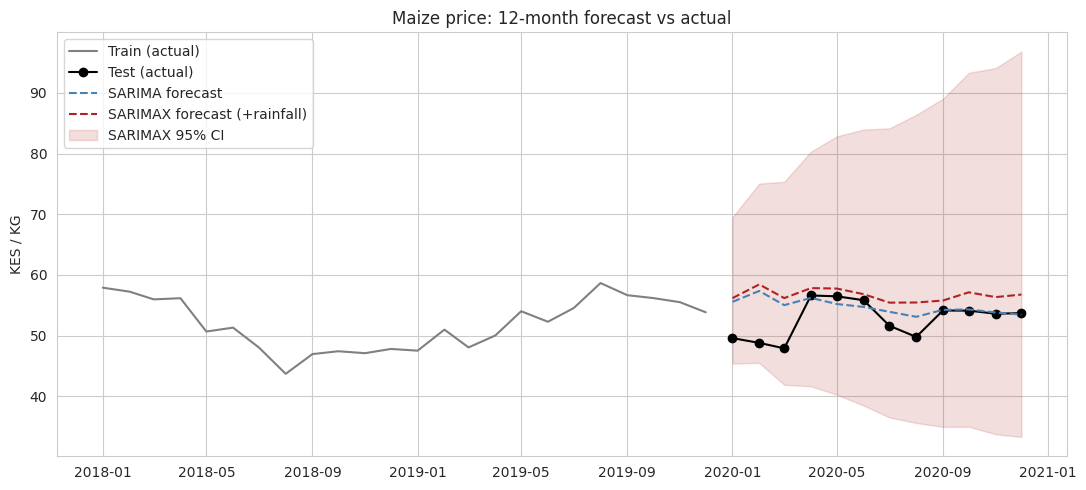

In [28]:
forecast_sarima = fit_sarima.get_forecast(steps=n_test)
forecast_sarimax = fit_sarimax.get_forecast(steps=n_test, exog=test_rain)

pred_sarima = forecast_sarima.predicted_mean
pred_sarimax = forecast_sarimax.predicted_mean
ci_sarimax = forecast_sarimax.conf_int()

# Convert back from log scale to KES/KG for interpretability
actual_price_level = np.exp(test_price)
pred_sarima_level = np.exp(pred_sarima)
pred_sarimax_level = np.exp(pred_sarimax)
ci_sarimax_level = np.exp(ci_sarimax)

plt.figure(figsize=(11, 5))
plt.plot(np.exp(train_price.iloc[-24:]), label="Train (actual)", color="gray")
plt.plot(actual_price_level, label="Test (actual)", color="black", marker="o")
plt.plot(pred_sarima_level, label="SARIMA forecast", color="steelblue", linestyle="--")
plt.plot(pred_sarimax_level, label="SARIMAX forecast (+rainfall)", color="firebrick", linestyle="--")
plt.fill_between(ci_sarimax_level.index,
                  ci_sarimax_level.iloc[:, 0],
                  ci_sarimax_level.iloc[:, 1],
                  color="firebrick", alpha=0.15, label="SARIMAX 95% CI")
plt.title("Maize price: 12-month forecast vs actual")
plt.ylabel("KES / KG")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

print("Evaluation on held-out 12 months (KES/KG scale):")
print(f"  SARIMA  — MAE: {mean_absolute_error(actual_price_level, pred_sarima_level):.2f}   RMSE: {rmse(actual_price_level, pred_sarima_level):.2f}")
print(f"  SARIMAX — MAE: {mean_absolute_error(actual_price_level, pred_sarimax_level):.2f}   RMSE: {rmse(actual_price_level, pred_sarimax_level):.2f}")

Evaluation on held-out 12 months (KES/KG scale):
  SARIMA  — MAE: 2.57   RMSE: 3.86
  SARIMAX — MAE: 4.00   RMSE: 4.87


**Interpreting this:**
- Compare AIC and out-of-sample MAE/RMSE between the two models. If SARIMAX (with rainfall) doesn't clearly beat plain SARIMA, it may be because rainfall affects price with a **lag** (e.g. 3–6 months, tied to harvest timing) rather than the same month — worth testing `rain_ts.shift(k)` as the exogenous variable for a few different lags `k`.
- 12 months is a short test window; results can be noisy. Consider walk-forward validation (refit and forecast 1 step at a time, rolling through more of the history) for a more robust comparison.
- This order `(1,1,1)(1,1,0,12)` is a starting point, not a tuned model — grid-search over `(p,d,q)(P,D,Q,12)` combinations by AIC, or use `pmdarima.auto_arima(train_price, seasonal=True, m=12)` if you install `pmdarima`.

---
# Refining the Forecast: Lagged Rainfall + ARIMA Order Search

The first SARIMAX attempt used rainfall in the *same month* as price, and it didn't beat plain SARIMA out-of-sample. Two likely reasons:
1. **Wrong lag** — a drought affects the harvest, which affects supply and price, months later — not the same month.
2. **Untuned order** — `(1,1,1)(1,1,0,12)` was a reasonable starting guess, not a fitted choice.

This section tackles both: first find the best rainfall lag, then grid-search the ARIMA order using that lag.

## Step 1: Test several rainfall lags

For each candidate lag (0–12 months), refit the same `SARIMAX(1,1,1)(1,1,0,12)` on the training data and compare AIC (in-sample fit) and out-of-sample MAE on the same 12-month test window used before.

In [30]:
candidate_lags = [0, 1, 2, 3, 4, 5, 6, 9, 12]
lag_results = []

for lag in candidate_lags:
    rain_lagged_full = rain_aligned.shift(lag)

    # Rebuild train/test with this lag, dropping the NaNs the shift introduces at the start
    combined = pd.concat([log_price_aligned, rain_lagged_full], axis=1).dropna()
    combined.columns = ["price", "rain_lag"]

    if len(combined) <= n_test + 24:
        # Not enough data left after shifting to fit reliably
        continue

    train_c = combined.iloc[:-n_test]
    test_c = combined.iloc[-n_test:]

    try:
        m = sm.tsa.statespace.SARIMAX(
            train_c["price"],
            exog=train_c[["rain_lag"]],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        f = m.fit(disp=False)
        fc = f.get_forecast(steps=n_test, exog=test_c[["rain_lag"]])
        pred_level = np.exp(fc.predicted_mean)
        actual_level = np.exp(test_c["price"])
        mae = mean_absolute_error(actual_level, pred_level)
        lag_results.append({"lag_months": lag, "AIC": f.aic, "test_MAE": mae})
    except Exception as e:
        print(f"Lag {lag} failed: {e}")

lag_df = pd.DataFrame(lag_results).sort_values("test_MAE")
lag_df

,lag_months,AIC,test_MAE
3,3,-219.267170,2.563783
4,4,-214.912834,2.635701
2,2,-211.117161,2.832919
1,1,-213.193399,2.841488
5,5,-214.539296,2.898282
6,6,-207.463090,3.099612
7,9,-200.339878,3.297989
8,12,-196.458036,3.801650
0,0,-217.129347,3.996646


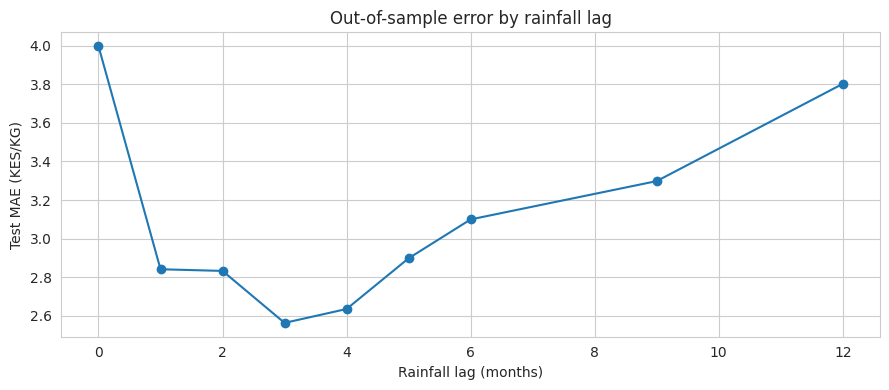

Best lag by test MAE: 3 months (MAE=2.564, AIC=-219.27)
Plain SARIMA (no rainfall) test MAE was: 2.569


In [32]:
plt.figure(figsize=(9, 4))
plt.plot(lag_df.sort_values("lag_months")["lag_months"], lag_df.sort_values("lag_months")["test_MAE"], marker="o")
plt.xlabel("Rainfall lag (months)")
plt.ylabel("Test MAE (KES/KG)")
plt.title("Out-of-sample error by rainfall lag")
plt.tight_layout()
plt.show()

best_lag = int(lag_df.iloc[0]["lag_months"])
print(f"Best lag by test MAE: {best_lag} months (MAE={lag_df.iloc[0]['test_MAE']:.3f}, AIC={lag_df.iloc[0]['AIC']:.2f})")
print(f"Plain SARIMA (no rainfall) test MAE was: {mean_absolute_error(actual_price_level, pred_sarima_level):.3f}")

**Interpreting this:** if the best lag's MAE is still not below the plain-SARIMA MAE, that's a legitimate result too — it would mean, at least for this simple model structure, rainfall (at a monthly national-average resolution) doesn't add predictive value over letting the price series' own momentum drive the forecast. That can happen when: rainfall is only one of many price drivers (fuel costs, imports, exchange rate, policy), or national-average rainfall smooths out the regional variation that actually matters for maize-growing areas specifically.

## Step 2: Grid search the ARIMA order

Using the best rainfall lag found above (or no exogenous variable if none helped), grid-search over `(p,d,q)` and seasonal `(P,D,Q)` combinations, selecting by AIC on the training data. Kept deliberately small (`p,q,P,Q ∈ {0,1,2}`, `d=D=1` fixed based on the earlier ADF findings) since a full search grows very quickly and most of that space fits badly or fails to converge.

In [33]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# Use the best lag from Step 1 (falls back to no exog if lag 0 or a poor result)
use_exog = best_lag is not None
if use_exog:
    rain_lagged_full = rain_aligned.shift(best_lag)
    combined = pd.concat([log_price_aligned, rain_lagged_full], axis=1).dropna()
    combined.columns = ["price", "rain_lag"]
    train_g = combined.iloc[:-n_test]
    test_g = combined.iloc[-n_test:]
    exog_train, exog_test = train_g[["rain_lag"]], test_g[["rain_lag"]]
    price_train_g, price_test_g = train_g["price"], test_g["price"]
else:
    exog_train, exog_test = None, None
    price_train_g, price_test_g = train_price, test_price

p = q = P = Q = range(0, 3)  # 0, 1, 2
d, D, s = 1, 1, 12

grid_results = []
for p_, q_, P_, Q_ in itertools.product(p, q, P, Q):
    try:
        m = sm.tsa.statespace.SARIMAX(
            price_train_g,
            exog=exog_train,
            order=(p_, d, q_),
            seasonal_order=(P_, D, Q_, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        f = m.fit(disp=False)
        grid_results.append({
            "order": (p_, d, q_),
            "seasonal_order": (P_, D, Q_, s),
            "AIC": f.aic,
        })
    except Exception:
        continue

grid_df = pd.DataFrame(grid_results).sort_values("AIC").reset_index(drop=True)
print(f"{len(grid_df)} models converged out of {3**4} combinations tried")
grid_df.head(10)

81 models converged out of 81 combinations tried


,order,seasonal_order,AIC
0,"(1, 1, 0)","(0, 1, 1, 12)",-266.697478
1,"(2, 1, 0)","(0, 1, 1, 12)",-264.026453
2,"(1, 1, 1)","(0, 1, 1, 12)",-262.618372
3,"(0, 1, 1)","(0, 1, 1, 12)",-262.509809
4,"(2, 1, 1)","(0, 1, 1, 12)",-260.449924
5,"(0, 1, 2)","(0, 1, 1, 12)",-260.268988
6,"(2, 1, 2)","(0, 1, 1, 12)",-256.433606
7,"(1, 1, 2)","(0, 1, 1, 12)",-256.290076
8,"(2, 1, 1)","(1, 1, 1, 12)",-253.710055
9,"(1, 1, 0)","(1, 1, 1, 12)",-248.721402


## Refit the best order and evaluate out-of-sample

In [34]:
best_row = grid_df.iloc[0]
best_order = best_row["order"]
best_seasonal_order = best_row["seasonal_order"]
print(f"Best order: {best_order}{best_seasonal_order}  (AIC={best_row['AIC']:.2f}, "
      f"rainfall lag={'none' if not use_exog else str(best_lag) + ' months'})")

final_model = sm.tsa.statespace.SARIMAX(
    price_train_g,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_fit = final_model.fit(disp=False)

final_forecast = final_fit.get_forecast(steps=n_test, exog=exog_test)
final_pred_level = np.exp(final_forecast.predicted_mean)
final_ci_level = np.exp(final_forecast.conf_int())
actual_level_g = np.exp(price_test_g)

print(f"\nTuned model  — MAE: {mean_absolute_error(actual_level_g, final_pred_level):.2f}   "
      f"RMSE: {rmse(actual_level_g, final_pred_level):.2f}")
print(f"Original SARIMA (untuned, no rainfall) — MAE: {mean_absolute_error(actual_price_level, pred_sarima_level):.2f}   "
      f"RMSE: {rmse(actual_price_level, pred_sarima_level):.2f}")

Best order: (1, 1, 0)(0, 1, 1, 12)  (AIC=-266.70, rainfall lag=3 months)

Tuned model  — MAE: 4.23   RMSE: 4.76
Original SARIMA (untuned, no rainfall) — MAE: 2.57   RMSE: 3.86


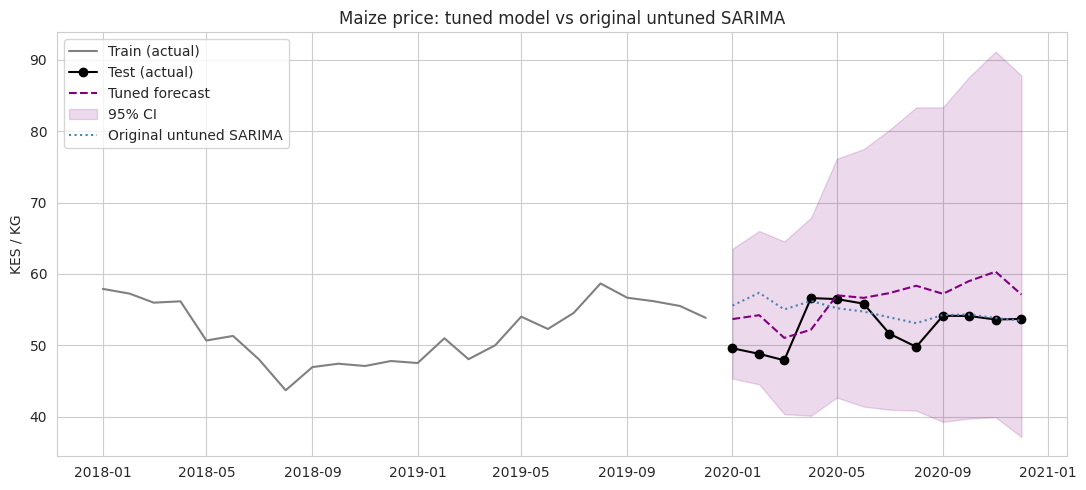

In [35]:
plt.figure(figsize=(11, 5))
plt.plot(np.exp(price_train_g.iloc[-24:]), label="Train (actual)", color="gray")
plt.plot(actual_level_g, label="Test (actual)", color="black", marker="o")
plt.plot(final_pred_level, label="Tuned forecast", color="purple", linestyle="--")
plt.fill_between(final_ci_level.index, final_ci_level.iloc[:, 0], final_ci_level.iloc[:, 1],
                  color="purple", alpha=0.15, label="95% CI")
plt.plot(pred_sarima_level, label="Original untuned SARIMA", color="steelblue", linestyle=":")
plt.title("Maize price: tuned model vs original untuned SARIMA")
plt.ylabel("KES / KG")
plt.legend()
plt.tight_layout()
plt.show()

**Takeaways:**
- The grid search only optimizes **AIC on the training set**, which doesn't always translate to better out-of-sample accuracy (AIC penalizes complexity but can still overfit patterns specific to the training period) — that's why we check test MAE/RMSE separately rather than trusting AIC alone.
- If the tuned model still doesn't clearly beat the untuned baseline, the practical takeaway is that a single held-out 12-month window may be too small/noisy to distinguish between models confidently. **Walk-forward validation** (retrain and forecast repeatedly across many rolling windows, then average the error) would give a more reliable comparison — happy to build that out next if useful.
- `pmdarima.auto_arima` automates this same search (and adds stepwise search + more diagnostics) if you want a faster/more thorough version outside this manual grid.

---
# Walk-Forward Validation

A single 12-month test window can easily make one model look better than another just by chance — the "best" model above (AIC-tuned order) actually did *worse* out-of-sample than the untuned baseline, which is a sign we shouldn't trust one window too far.

**Walk-forward validation** fixes this by repeatedly moving the training cutoff forward through history, refitting at each point, forecasting 12 months ahead, and averaging the error across many such origins — an *expanding window* backtest, which mimics how the model would actually have been used in practice (retrained periodically as new months of data arrive).

We compare three fixed model specifications across all origins (the order/exog choices themselves are **not** re-tuned per origin — that would leak future information into the selection):

1. **Baseline** — `SARIMA(1,1,1)(1,1,0,12)`, price only (the original untuned model)
2. **Rainfall lag-3** — same order, with rainfall lagged 3 months as an exogenous regressor (the best lag found earlier)
3. **AIC-tuned order** — `SARIMA(1,1,0)(0,1,1,12)`, price only (the order the grid search preferred)

In [36]:
def walk_forward_eval(price_series, order, seasonal_order, exog_series=None,
                       min_train=72, horizon=12, step=6):
    """Expanding-window walk-forward backtest.

    At each origin, train on all data up to that point, forecast `horizon` months
    ahead, and record the error against the actual values. Origins are spaced
    `step` months apart, starting once at least `min_train` months are available
    and stopping once there isn't a full `horizon`-month test window left.
    """
    n = len(price_series)
    origins = list(range(min_train, n - horizon, step))
    fold_errors = []

    for origin in origins:
        train_y = price_series.iloc[:origin]
        test_y = price_series.iloc[origin:origin + horizon]

        train_x = exog_series.iloc[:origin] if exog_series is not None else None
        test_x = exog_series.iloc[origin:origin + horizon] if exog_series is not None else None

        # Skip this fold if the exogenous series has NaNs in range (from lagging)
        if train_x is not None and (train_x.isna().any() or test_x.isna().any()):
            continue

        try:
            model = sm.tsa.statespace.SARIMAX(
                train_y, exog=train_x, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            fc = fit.get_forecast(steps=horizon, exog=test_x)
            pred_level = np.exp(fc.predicted_mean)
            actual_level = np.exp(test_y)
            mae = mean_absolute_error(actual_level, pred_level)
            rmse_val = rmse(actual_level, pred_level)
            fold_errors.append({
                "origin_date": price_series.index[origin - 1],
                "MAE": mae,
                "RMSE": rmse_val,
            })
        except Exception as e:
            print(f"  origin {price_series.index[origin - 1].date()} failed: {e}")

    return pd.DataFrame(fold_errors)

In [37]:
rain_lag3 = rain_aligned.shift(3)

# Restrict to the range where the lagged rainfall is actually defined (drop the
# first 3 months introduced as NaN by the shift) before running the exog variant.
valid_idx = rain_lag3.dropna().index
price_for_lag3 = log_price_aligned.loc[valid_idx]
rain_lag3_valid = rain_lag3.loc[valid_idx]

print("Running walk-forward: Baseline (no exog)...")
wf_baseline = walk_forward_eval(log_price_aligned, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))

print("Running walk-forward: Rainfall lag-3...")
wf_lag3 = walk_forward_eval(price_for_lag3, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12), exog_series=rain_lag3_valid)

print("Running walk-forward: AIC-tuned order (no exog)...")
wf_tuned = walk_forward_eval(log_price_aligned, order=(1, 1, 0), seasonal_order=(0, 1, 1, 12))

print(f"\nFolds completed — Baseline: {len(wf_baseline)}, Lag-3: {len(wf_lag3)}, Tuned: {len(wf_tuned)}")

Running walk-forward: Baseline (no exog)...
Running walk-forward: Rainfall lag-3...
Running walk-forward: AIC-tuned order (no exog)...

Folds completed — Baseline: 16, Lag-3: 16, Tuned: 16


In [38]:
wf_summary = pd.DataFrame([
    {"model": "Baseline (1,1,1)(1,1,0,12)", "mean MAE": wf_baseline["MAE"].mean(),
     "mean RMSE": wf_baseline["RMSE"].mean(), "n folds": len(wf_baseline)},
    {"model": "Rainfall lag-3, same order", "mean MAE": wf_lag3["MAE"].mean(),
     "mean RMSE": wf_lag3["RMSE"].mean(), "n folds": len(wf_lag3)},
    {"model": "AIC-tuned (1,1,0)(0,1,1,12)", "mean MAE": wf_tuned["MAE"].mean(),
     "mean RMSE": wf_tuned["RMSE"].mean(), "n folds": len(wf_tuned)},
]).round(3)
wf_summary

,model,mean MAE,mean RMSE,n folds
0,"Baseline (1,1,1)(1,1,0,12)",7.516,8.804,16
1,"Rainfall lag-3, same order",7.197,8.576,16
2,"AIC-tuned (1,1,0)(0,1,1,12)",6.046,7.181,16


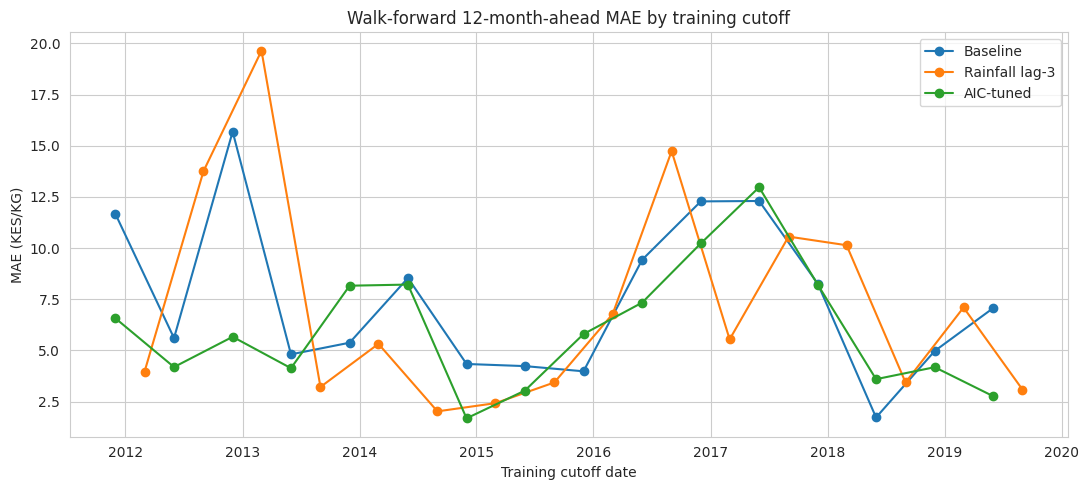

In [39]:
plt.figure(figsize=(11, 5))
plt.plot(wf_baseline["origin_date"], wf_baseline["MAE"], marker="o", label="Baseline")
plt.plot(wf_lag3["origin_date"], wf_lag3["MAE"], marker="o", label="Rainfall lag-3")
plt.plot(wf_tuned["origin_date"], wf_tuned["MAE"], marker="o", label="AIC-tuned")
plt.title("Walk-forward 12-month-ahead MAE by training cutoff")
plt.ylabel("MAE (KES/KG)")
plt.xlabel("Training cutoff date")
plt.legend()
plt.tight_layout()
plt.show()

**Reading this:**
- The **mean MAE/RMSE across all folds** is the reliable comparison — much sturdier than the single-window result from before, since it isn't dependent on whichever 12 months happened to be held out.
- The **plot by training cutoff** shows *when* each model struggles — if one model is consistently worse across most cutoffs, that's real; if it only loses on one or two folds (e.g. around a price shock like the 2016–17 spike), that's more about how forecastable that specific period was for any model, not a fundamental flaw.
- If the baseline still wins on average here, that's the honest conclusion for this dataset: the added complexity (rainfall, tuned seasonal order) isn't earning its keep on a single-market, national-average monthly series. That's a legitimate finding to report, not a failure — it tells you where *not* to spend further modeling effort, and suggests any real gain would more likely come from better inputs (e.g. region-specific rainfall matched to region-specific price, or additional drivers like fuel cost/exchange rate) rather than a more complex model on the same two variables.

---
# Crop Yield / Long-Term Trends (placeholder)

No yield dataset has been provided yet. Once one is available (e.g. tonnes/hectare by year and region), the same workflow applies directly:

1. Convert to a time series (likely annual rather than monthly, given how yield data is usually reported)
2. Plot and visually inspect for trend
3. Rolling statistics (a shorter window, e.g. 3–5 years, given annual frequency)
4. ADF test
5. Transform if needed (yield trends are often closer to linear than exponential, so differencing alone — without a log transform — may be enough)
6. Plot the transformed series
7. Re-run ADF

Given the annual frequency, this series will have far fewer observations than the monthly price/rainfall series, which limits how complex a model (e.g. SARIMA seasonal order) can reliably be fit — a simple trend + ARIMA(p,d,q) on annual data, or even a Mann-Kendall trend test, may be more appropriate than a full seasonal model.

---
# All Crops: Automated Time Series EDA

Everything above was a worked example on a single commodity (Maize (white)). This section repeats the **same 7-step process** — convert to time series, plot, rolling stats, ADF, transform, plot transformed, ADF again — automatically across **every crop in the dataset** that has enough monthly history to analyze.

**Scope decisions:**
- **Price type**: Retail only (more complete than Wholesale for most commodities).
- **Aggregation**: national monthly average, same as the maize example.
- **Minimum history**: commodities need **at least 24 months** of data — shorter than that and rolling statistics (12-month window) and seasonal patterns aren't meaningful.
- **Excluded categories**: `Salt`, `Fuel (diesel/petrol/kerosene)`, `Milk (*)`, `Meat (*)`, and `Bread` are dropped — these aren't crops. Commodities like `Sugar`, `Oil (vegetable)`, `Wheat flour`, and `Maize flour` are kept since they're direct crop derivatives.

Run the cell below to see which commodities qualify.

In [40]:
EXCLUDE_KEYWORDS = ["Salt", "Fuel", "Milk", "Meat", "Bread"]

retail = df[df["pricetype"] == "Retail"].copy()

def is_crop(commodity):
    return not any(kw in commodity for kw in EXCLUDE_KEYWORDS)

coverage = (
    retail.groupby("commodity")["date"]
    .apply(lambda s: s.dt.to_period("M").nunique())
    .sort_values(ascending=False)
)

MIN_MONTHS = 24
qualifying_crops = [c for c in coverage.index if is_crop(c) and coverage[c] >= MIN_MONTHS]

print(f"{len(qualifying_crops)} crops qualify (>= {MIN_MONTHS} months of Retail data):\n")
for c in qualifying_crops:
    print(f"  {c:<20s} {coverage[c]} months")

11 crops qualify (>= 24 months of Retail data):

  Oil (vegetable)      238 months
  Beans (dry)          227 months
  Maize (white)        180 months
  Rice                 63 months
  Bananas              63 months
  Maize flour          63 months
  Potatoes (Irish)     63 months
  Sugar                63 months
  Wheat flour          62 months
  Maize                59 months
  Sorghum              56 months


## Build each crop's time series

For each qualifying crop we build the same national monthly average series used for maize.

In [41]:
crop_series = {}
for crop in qualifying_crops:
    s = retail[retail["commodity"] == crop].groupby("date")["price"].mean().sort_index()
    s.index = pd.DatetimeIndex(s.index).to_period("M").to_timestamp()
    crop_series[crop] = s

# Quick sanity check on shapes
for crop, s in crop_series.items():
    print(f"{crop:<20s} {s.index.min().date()} -> {s.index.max().date()}  ({len(s)} obs)")

Oil (vegetable)      2006-01-01 -> 2026-08-01  (238 obs)
Beans (dry)          2006-02-01 -> 2026-08-01  (227 obs)
Maize (white)        2006-01-01 -> 2020-12-01  (180 obs)
Rice                 2018-12-01 -> 2026-08-01  (63 obs)
Bananas              2018-12-01 -> 2026-08-01  (63 obs)
Maize flour          2018-12-01 -> 2026-08-01  (63 obs)
Potatoes (Irish)     2018-12-01 -> 2026-08-01  (63 obs)
Sugar                2018-12-01 -> 2026-08-01  (63 obs)
Wheat flour          2018-12-01 -> 2026-08-01  (62 obs)
Maize                2020-08-01 -> 2026-08-01  (59 obs)
Sorghum              2020-08-01 -> 2026-08-01  (56 obs)


## Steps 2–7, automated per crop

For each crop:
- Plot the raw series with its 12-month rolling mean/std
- Run ADF on the raw series
- If non-stationary (p ≥ 0.05): apply a log transform (only if all values are positive, which price data always is) followed by first-order differencing, then plot and re-run ADF
- If already stationary (p < 0.05): note that no transformation was needed

In [42]:
def analyze_crop(name, series, window=12):
    results = {}

    # --- raw plot + rolling stats, side by side ---
    roll_mean = series.rolling(window).mean()
    roll_std = series.rolling(window).std()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(series, color="steelblue")
    axes[0].set_title(f"{name}: raw price")
    axes[1].plot(series, label="Original", color="steelblue", alpha=0.6)
    axes[1].plot(roll_mean, label=f"Rolling mean ({window}m)", color="firebrick")
    axes[1].plot(roll_std, label=f"Rolling std ({window}m)", color="darkorange")
    axes[1].set_title(f"{name}: rolling mean/std")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- ADF on raw ---
    adf_raw = adfuller(series.dropna(), autolag="AIC")
    results["adf_raw_stat"] = adf_raw[0]
    results["adf_raw_p"] = adf_raw[1]
    results["adf_raw_lags"] = adf_raw[2]
    results["adf_raw_stationary"] = adf_raw[1] < 0.05

    print(f"[{name}] ADF (raw): statistic={adf_raw[0]:.4f}  p-value={adf_raw[1]:.5f}  "
          f"-> {'stationary' if adf_raw[1] < 0.05 else 'NON-stationary'}")

    # --- transform if needed ---
    if adf_raw[1] >= 0.05:
        transformed = np.log(series).diff().dropna()
        transform_label = "log + 1st-difference"

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(transformed, color="seagreen")
        axes[0].axhline(0, color="black", lw=0.8)
        axes[0].set_title(f"{name}: {transform_label}")
        t_roll_mean = transformed.rolling(window).mean()
        t_roll_std = transformed.rolling(window).std()
        axes[1].plot(transformed, label="Transformed", color="seagreen", alpha=0.6)
        axes[1].plot(t_roll_mean, label=f"Rolling mean ({window}m)", color="firebrick")
        axes[1].plot(t_roll_std, label=f"Rolling std ({window}m)", color="darkorange")
        axes[1].set_title(f"{name}: rolling mean/std (transformed)")
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        adf_t = adfuller(transformed.dropna(), autolag="AIC")
        results["transform"] = transform_label
        results["adf_final_stat"] = adf_t[0]
        results["adf_final_p"] = adf_t[1]
        results["adf_final_lags"] = adf_t[2]
        results["adf_final_stationary"] = adf_t[1] < 0.05

        print(f"[{name}] ADF ({transform_label}): statistic={adf_t[0]:.4f}  p-value={adf_t[1]:.5f}  "
              f"-> {'stationary' if adf_t[1] < 0.05 else 'STILL non-stationary'}")
    else:
        results["transform"] = "none needed"
        results["adf_final_stat"] = adf_raw[0]
        results["adf_final_p"] = adf_raw[1]
        results["adf_final_lags"] = adf_raw[2]
        results["adf_final_stationary"] = True

    print()
    return results

Oil (vegetable)


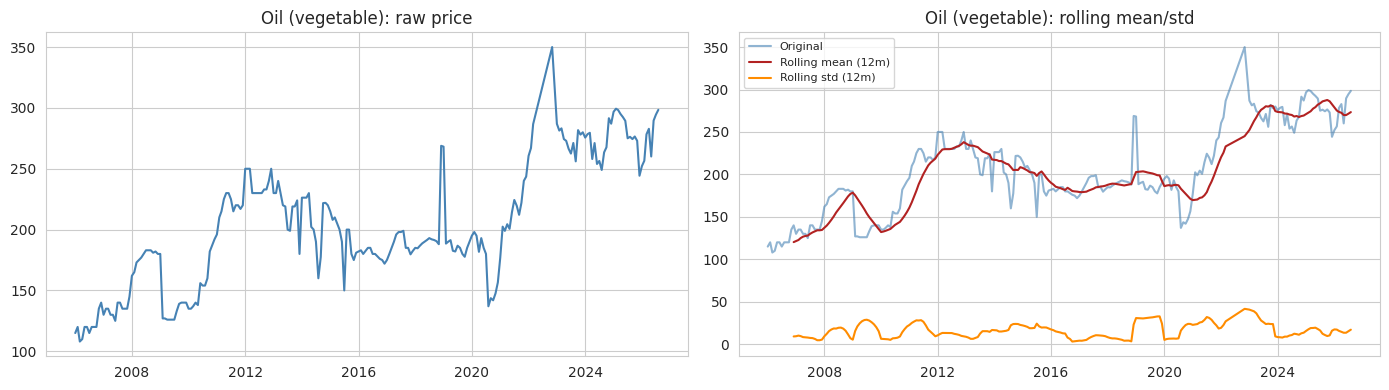

[Oil (vegetable)] ADF (raw): statistic=-1.8087  p-value=0.37613  -> NON-stationary


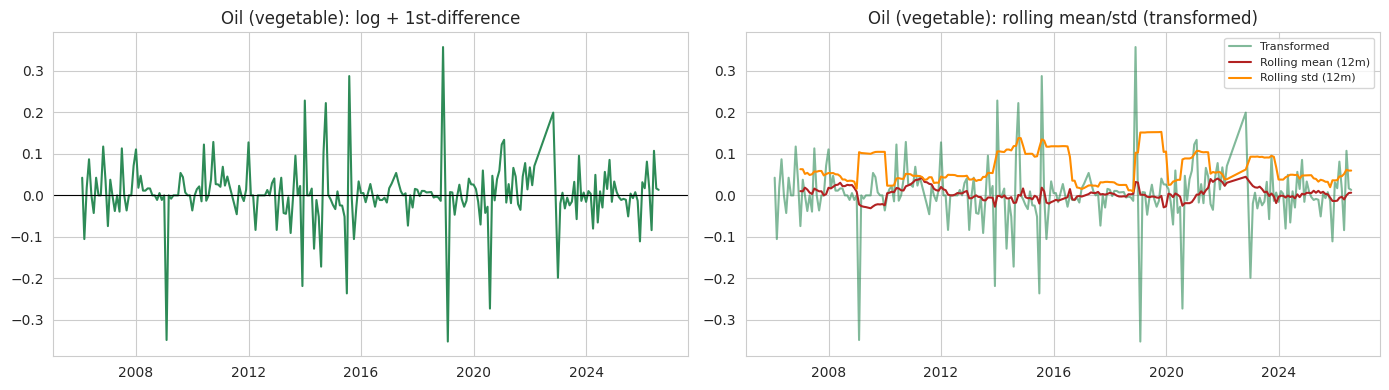

[Oil (vegetable)] ADF (log + 1st-difference): statistic=-13.0832  p-value=0.00000  -> stationary

Beans (dry)


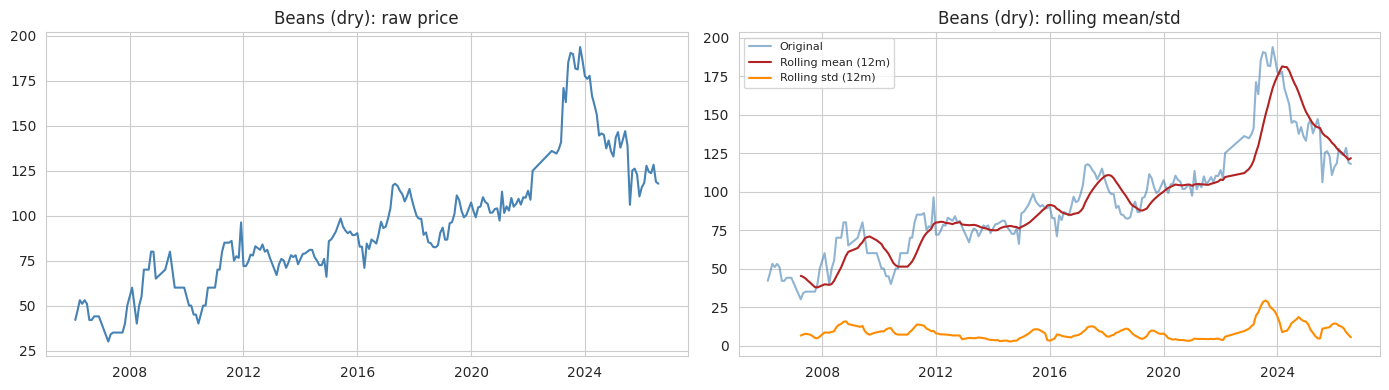

[Beans (dry)] ADF (raw): statistic=-1.9137  p-value=0.32564  -> NON-stationary


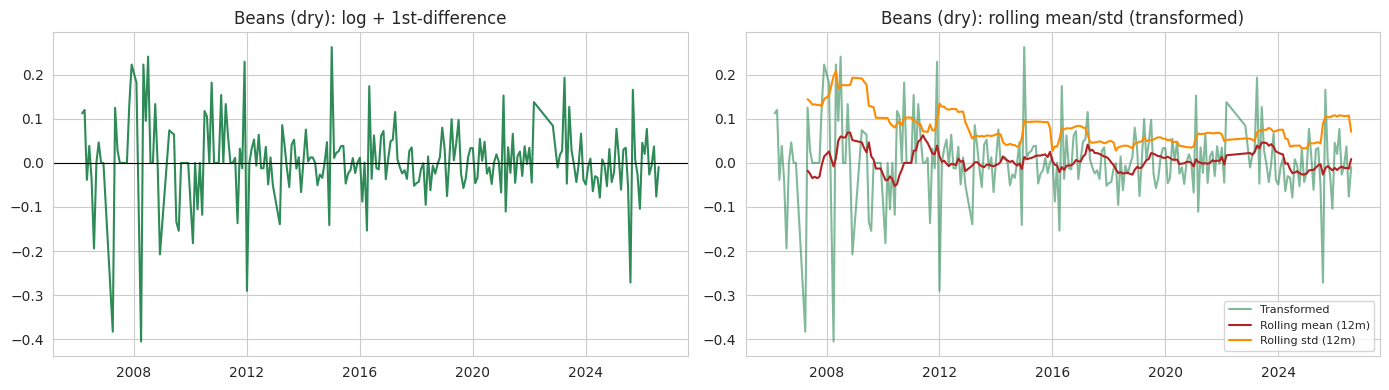

[Beans (dry)] ADF (log + 1st-difference): statistic=-5.9886  p-value=0.00000  -> stationary

Maize (white)


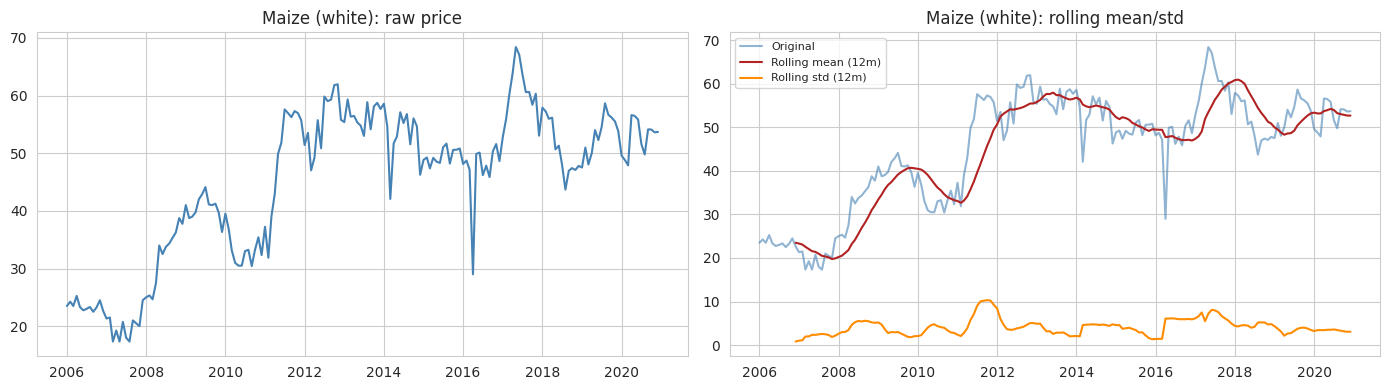

[Maize (white)] ADF (raw): statistic=-1.9155  p-value=0.32480  -> NON-stationary


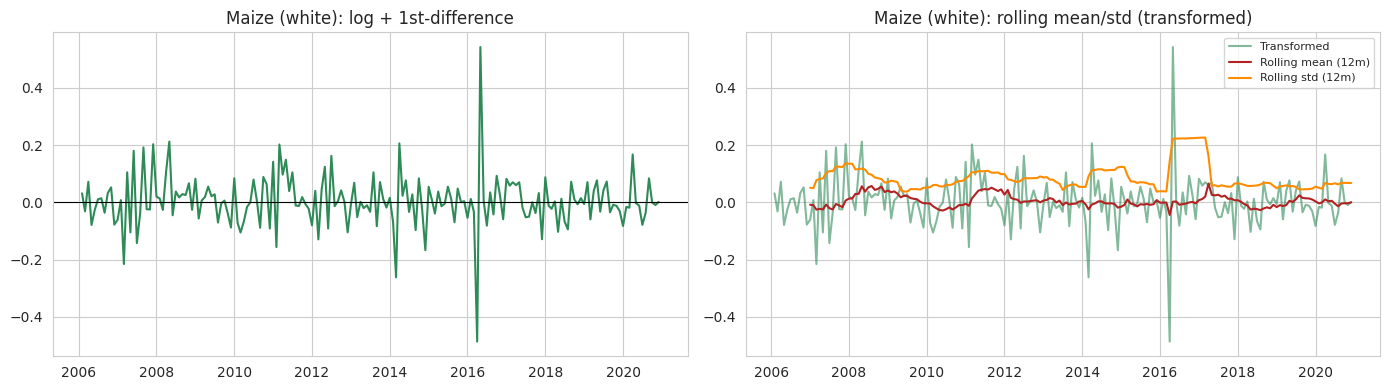

[Maize (white)] ADF (log + 1st-difference): statistic=-18.5194  p-value=0.00000  -> stationary

Rice


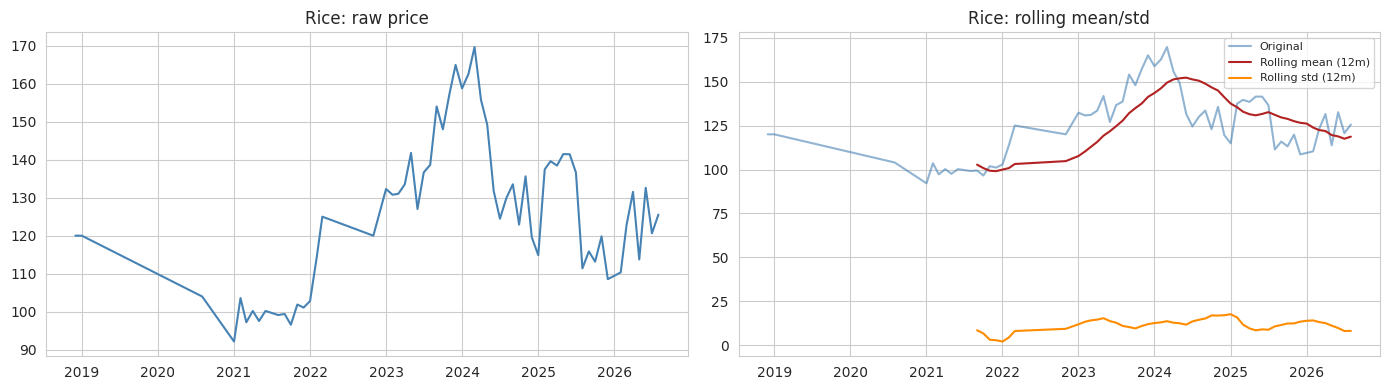

[Rice] ADF (raw): statistic=-1.9726  p-value=0.29872  -> NON-stationary


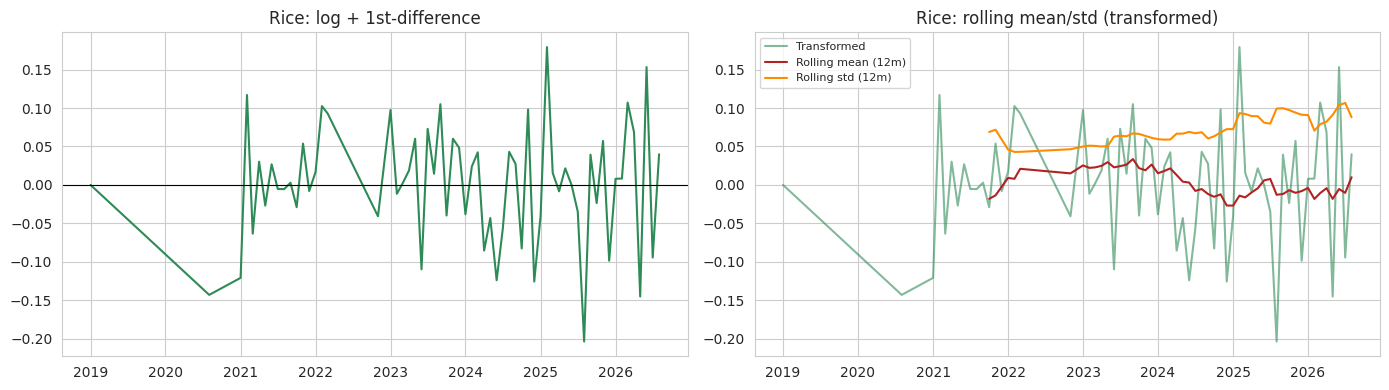

[Rice] ADF (log + 1st-difference): statistic=-9.8157  p-value=0.00000  -> stationary

Bananas


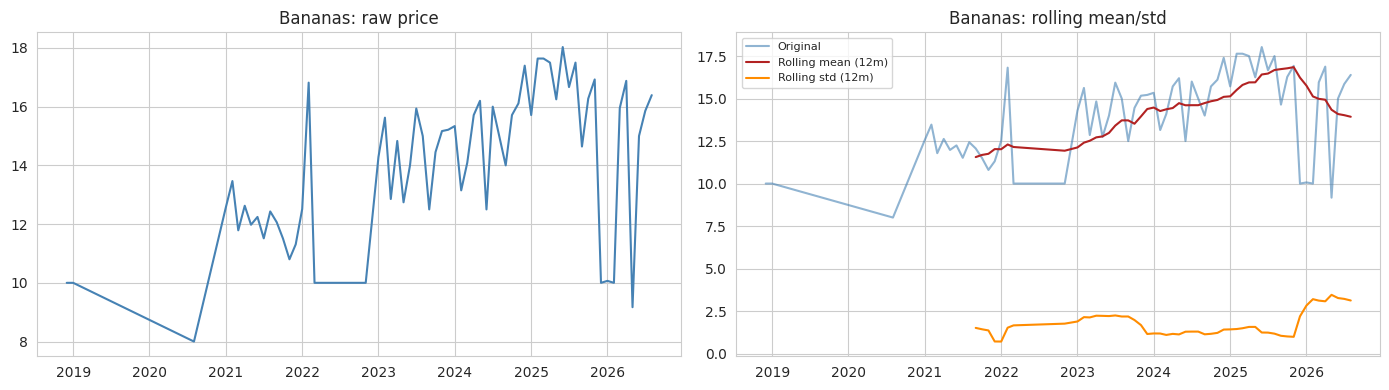

[Bananas] ADF (raw): statistic=-2.2243  p-value=0.19754  -> NON-stationary


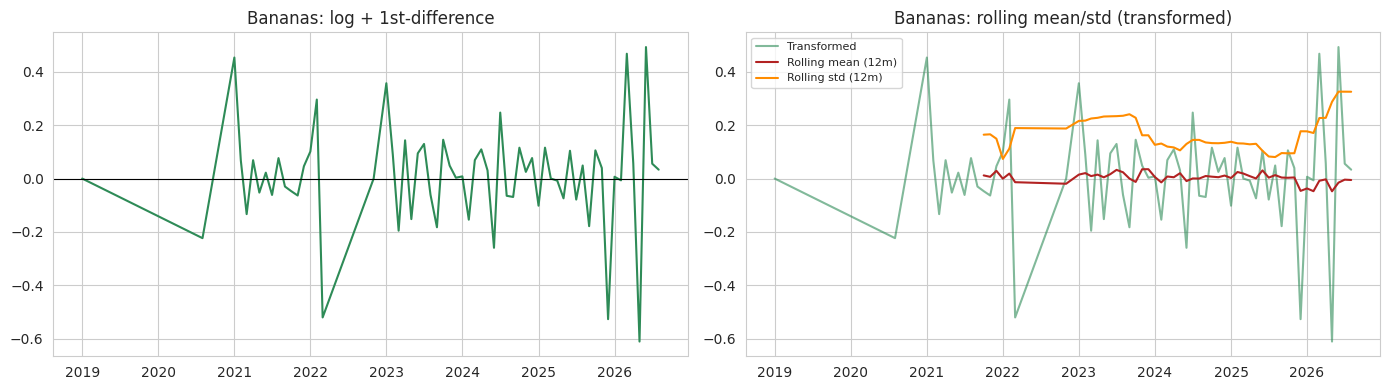

[Bananas] ADF (log + 1st-difference): statistic=-6.6016  p-value=0.00000  -> stationary

Maize flour


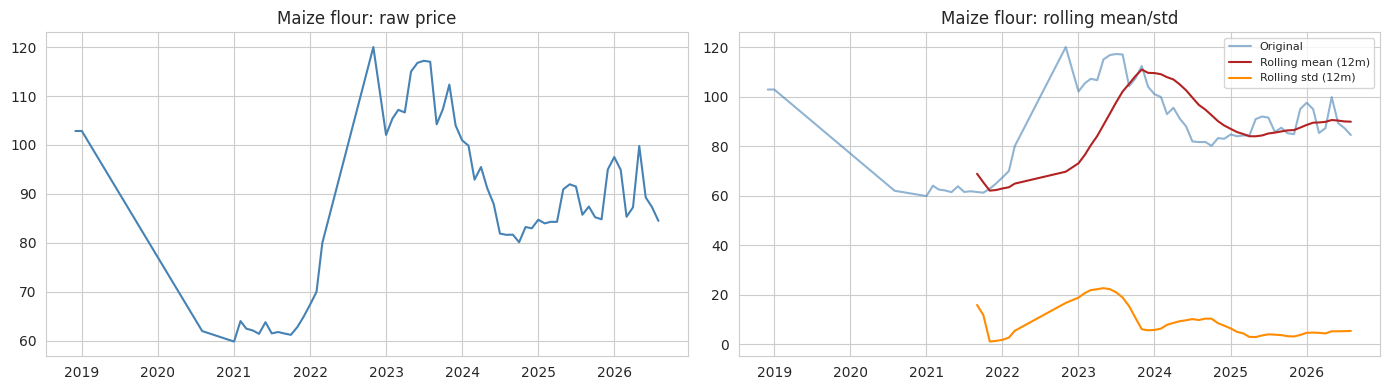

[Maize flour] ADF (raw): statistic=-2.1905  p-value=0.20971  -> NON-stationary


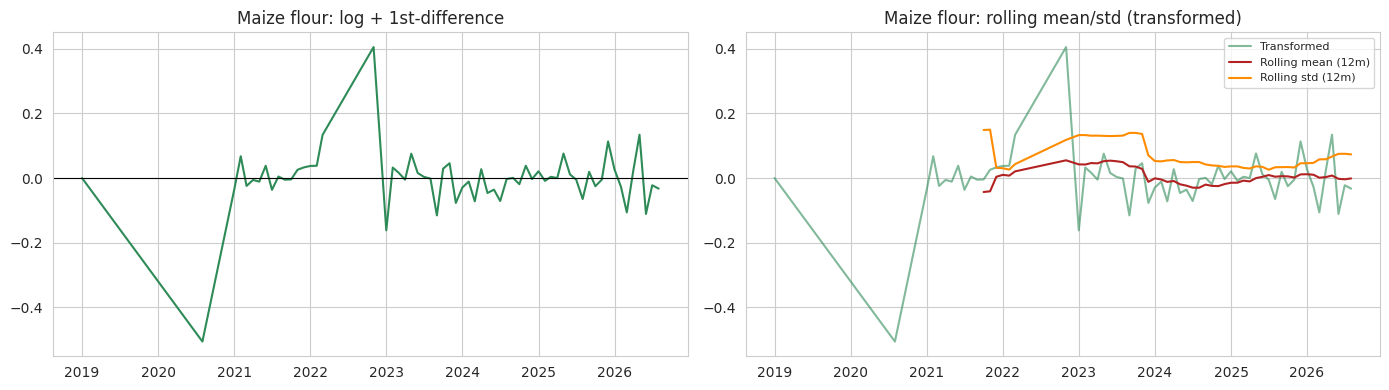

[Maize flour] ADF (log + 1st-difference): statistic=-7.7331  p-value=0.00000  -> stationary

Potatoes (Irish)


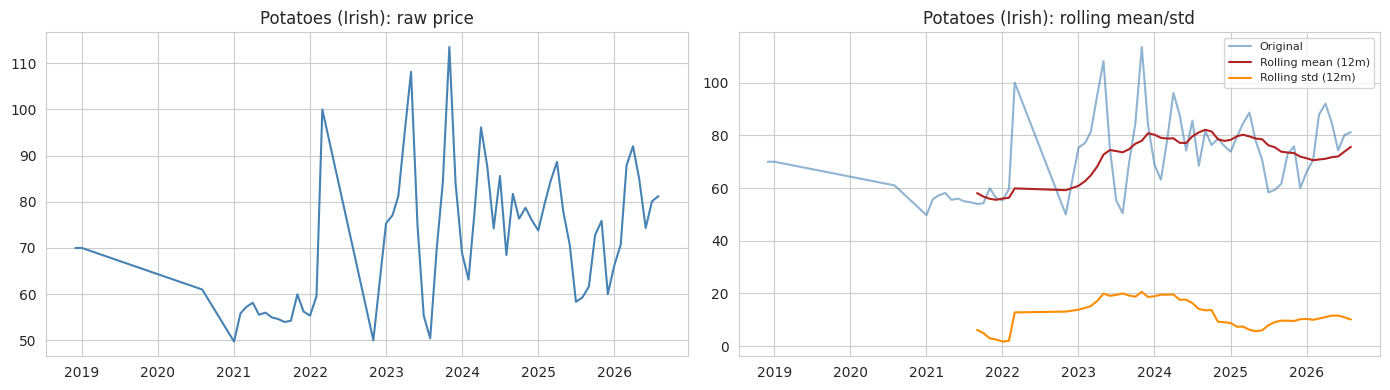

[Potatoes (Irish)] ADF (raw): statistic=-1.4207  p-value=0.57232  -> NON-stationary


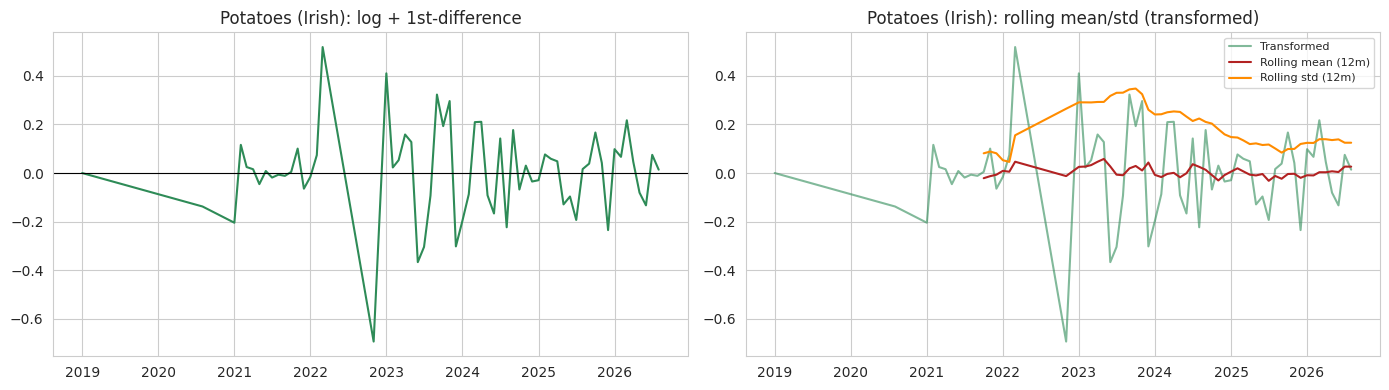

[Potatoes (Irish)] ADF (log + 1st-difference): statistic=-6.6000  p-value=0.00000  -> stationary

Sugar


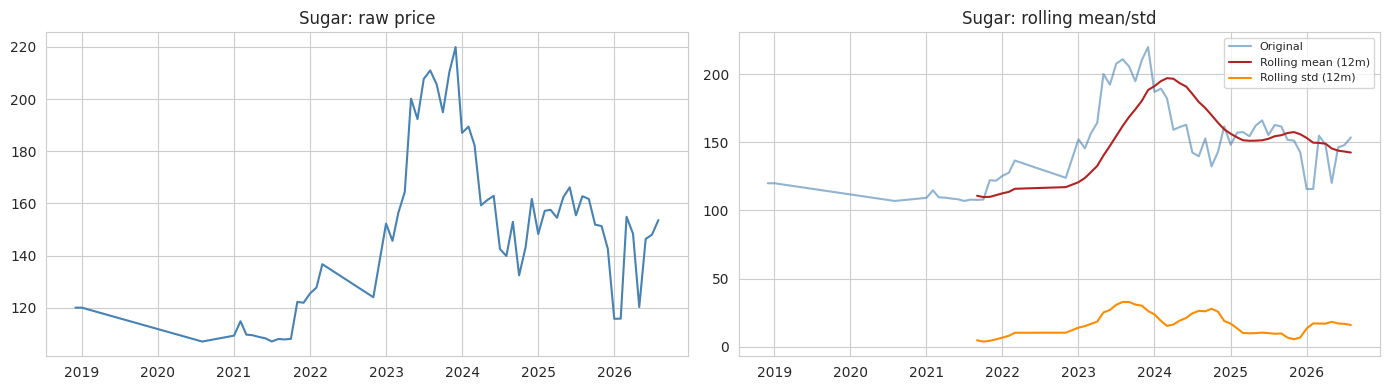

[Sugar] ADF (raw): statistic=-2.7596  p-value=0.06427  -> NON-stationary


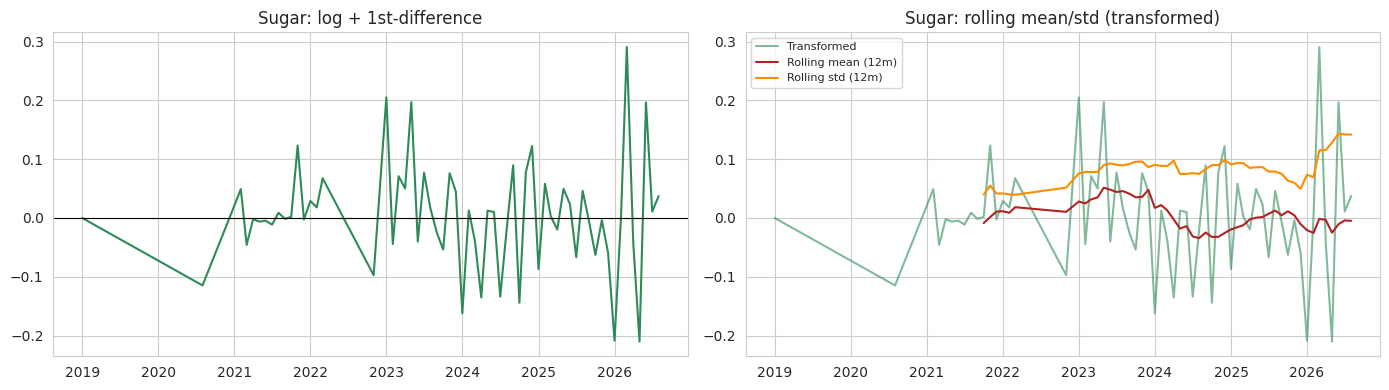

[Sugar] ADF (log + 1st-difference): statistic=-2.4544  p-value=0.12696  -> STILL non-stationary

Wheat flour


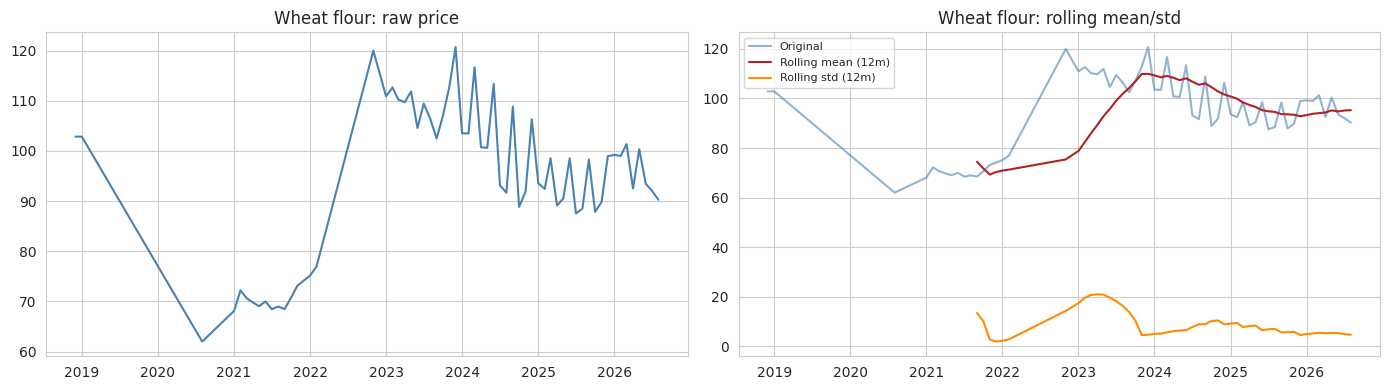

[Wheat flour] ADF (raw): statistic=-2.1076  p-value=0.24148  -> NON-stationary


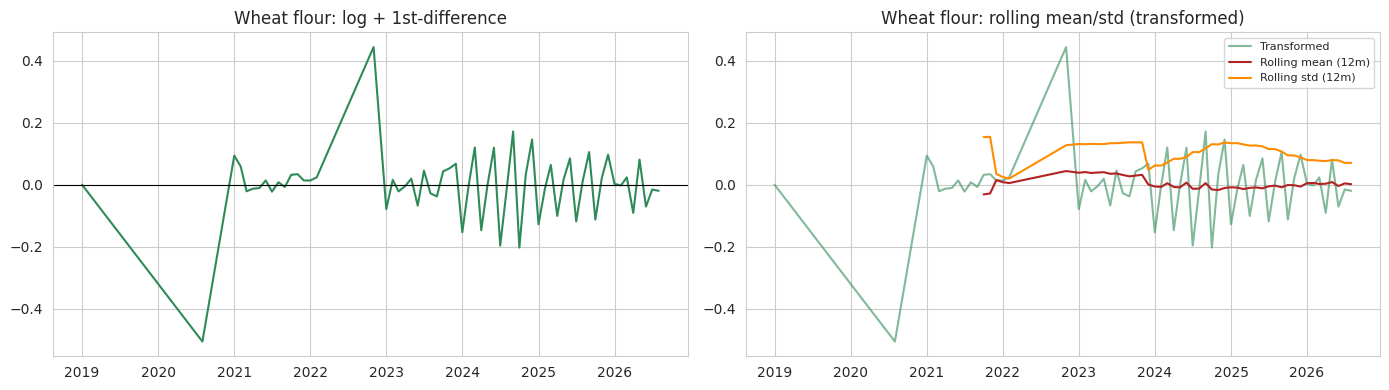

[Wheat flour] ADF (log + 1st-difference): statistic=-5.2219  p-value=0.00001  -> stationary

Maize


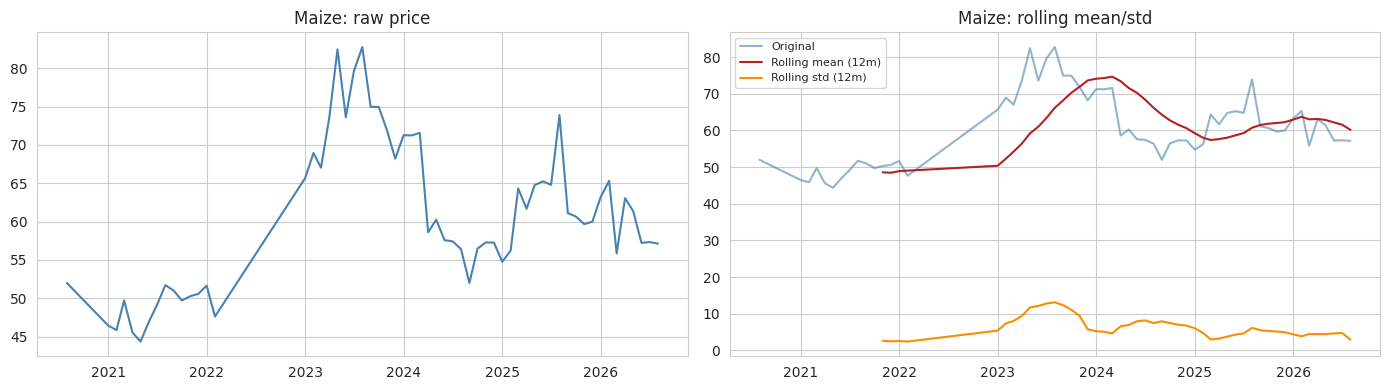

[Maize] ADF (raw): statistic=-2.3722  p-value=0.14973  -> NON-stationary


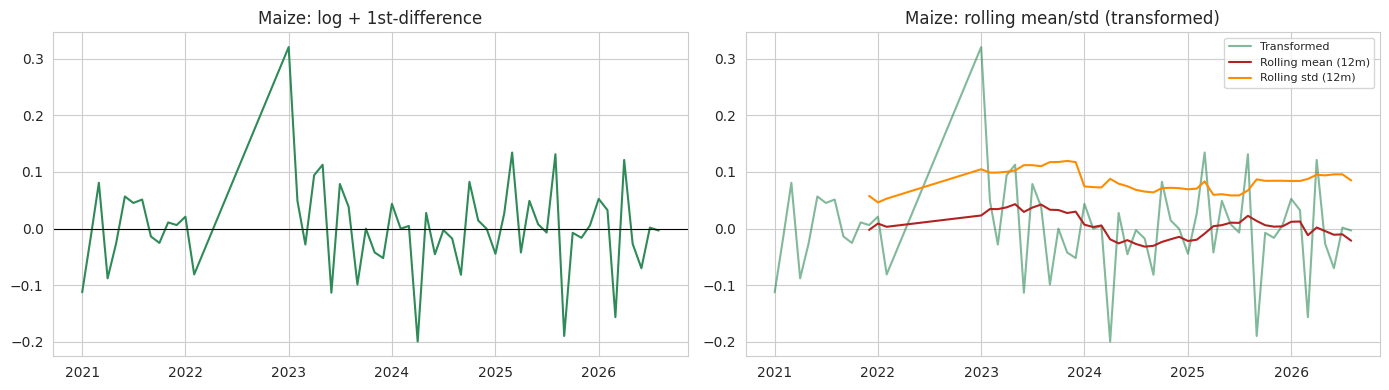

[Maize] ADF (log + 1st-difference): statistic=-9.6575  p-value=0.00000  -> stationary

Sorghum


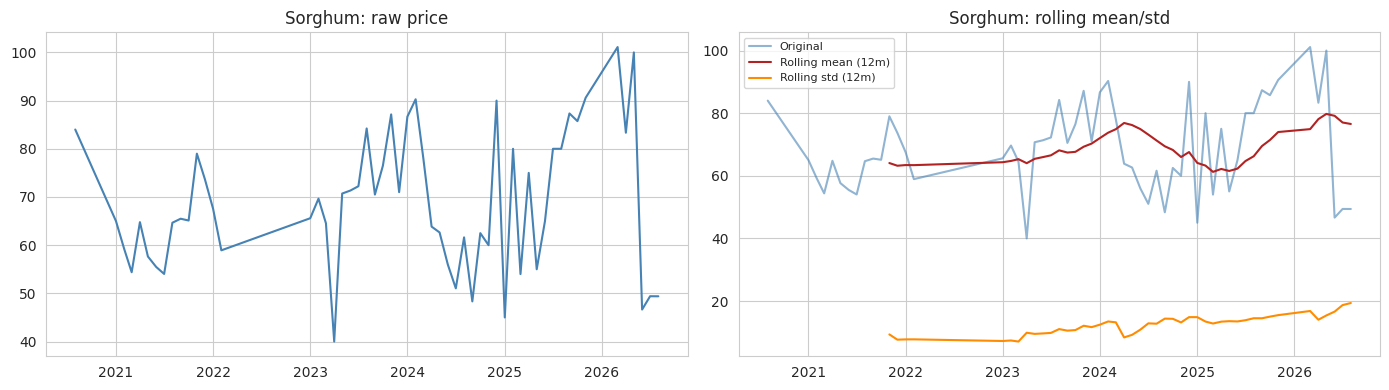

[Sorghum] ADF (raw): statistic=-2.5787  p-value=0.09747  -> NON-stationary


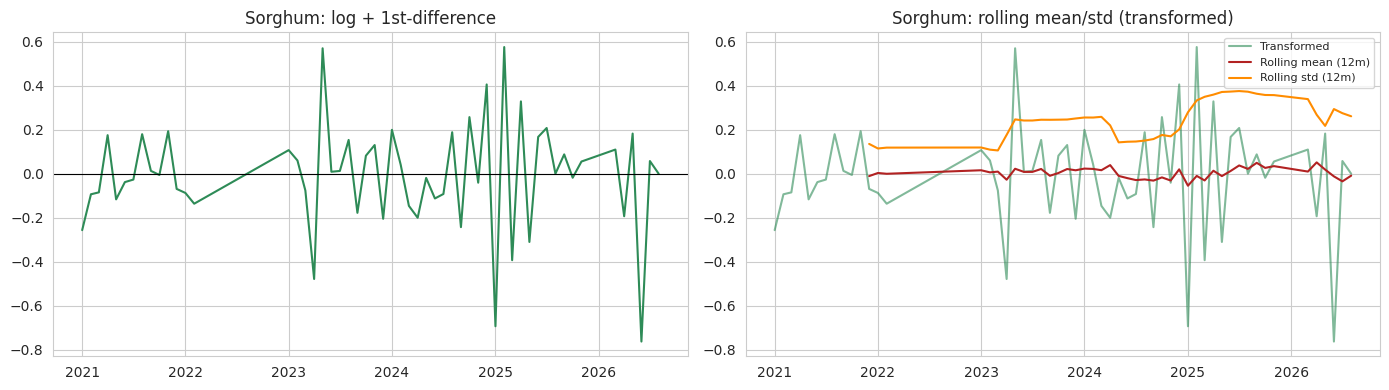

[Sorghum] ADF (log + 1st-difference): statistic=-13.7226  p-value=0.00000  -> stationary



In [43]:
all_results = {}
for crop, series in crop_series.items():
    print("=" * 70)
    print(crop)
    print("=" * 70)
    all_results[crop] = analyze_crop(crop, series)

## Master summary table — all crops

In [44]:
summary_rows = []
for crop, r in all_results.items():
    summary_rows.append({
        "crop": crop,
        "n_months": len(crop_series[crop]),
        "raw ADF p-value": round(r["adf_raw_p"], 5),
        "raw stationary?": r["adf_raw_stationary"],
        "transform applied": r["transform"],
        "final ADF p-value": round(r["adf_final_p"], 5),
        "final stationary?": r["adf_final_stationary"],
    })

all_crops_summary = pd.DataFrame(summary_rows).sort_values("crop").reset_index(drop=True)
all_crops_summary

,crop,n_months,raw ADF p-value,raw stationary?,transform applied,final ADF p-value,final stationary?
0,Bananas,63,0.19754,False,log + 1st-difference,0.00000,True
1,Beans (dry),227,0.32564,False,log + 1st-difference,0.00000,True
2,Maize,59,0.14973,False,log + 1st-difference,0.00000,True
3,Maize (white),180,0.32480,False,log + 1st-difference,0.00000,True
4,Maize flour,63,0.20971,False,log + 1st-difference,0.00000,True
5,Oil (vegetable),238,0.37613,False,log + 1st-difference,0.00000,True
6,Potatoes (Irish),63,0.57232,False,log + 1st-difference,0.00000,True
7,Rice,63,0.29872,False,log + 1st-difference,0.00000,True
8,Sorghum,56,0.09747,False,log + 1st-difference,0.00000,True
9,Sugar,63,0.06427,False,log + 1st-difference,0.12696,False


In [45]:
all_crops_summary.to_csv("all_crops_adf_summary.csv", index=False)
print("Saved to all_crops_adf_summary.csv")

Saved to all_crops_adf_summary.csv


**Reading this table:**
- **`raw stationary?` = False** for most crop prices is expected — like maize, most food commodity prices trend upward over time (inflation, demand growth) and are not stationary in levels.
- **`final stationary?`** should be `True` for almost all crops after log + first-differencing — if any crop is still `False`, it likely needs a second round of differencing or a longer/seasonal difference, similar to how rainfall needed a 12-month seasonal difference rather than a first difference.
- Crops with very few months (near the 24-month cutoff) will have noisier ADF results — treat those with extra caution before using them in any forecasting model.

### Next steps for all crops
- The `crop_series` dictionary and `all_results` from this loop can be fed directly into the same SARIMA/SARIMAX workflow used for maize earlier in this notebook — swap `log_price` for `np.log(crop_series["Rice"])` etc.
- Consider correlating each crop's differenced series with the rainfall series to see which crops are most rainfall-sensitive.